# 03 - Simple Baseline Model <a id="top"></a>

This notebook is the machine-learning endpoint of the project.

The previous notebooks introduced the synthetic silicon photonics dataset, explored the public measurements, and visualized spatial wafer-level patterns. This notebook asks a narrower supervised learning question:

> Can public inline metrology measurements predict downstream resonance wavelength for tested dies?

The target is `lambda_res_nm`, the measured downstream resonance wavelength. The model is trained only on dies that were tested downstream, because only those dies have a known target value.

The model uses only public inline metrology features. It does not use downstream measurements, pass/fail labels, identifiers, or hidden true generator variables as inputs.

The modeling is intentionally simple. This is a baseline sanity check, not an advanced production ML system.

## Contents

- [Load public data](#load-public-data)
- [Build supervised modeling table](#build-supervised-modeling-table)
- [Features and target](#features-and-target)
- [Wafer holdout split](#wafer-holdout-split)
- [Mean predictor sanity baseline](#mean-predictor-sanity-baseline)
- [Linear Regression baseline](#linear-regression-baseline)
- [Coefficient interpretation](#coefficient-interpretation)
- [Prediction diagnostics](#prediction-diagnostics)
- [Final interpretation](#final-interpretation)

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 40)

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from src.utils import load_sources, merge_sources, validate_schemas

## Load public data <a id="load-public-data"></a>

The project has two public tables.

`df_inline` contains one row per die. It contains measurements that would be available early through inline metrology.

`df_downstream` contains one row per tested die. It contains the downstream optical result, including the regression target `lambda_res_nm`.

A supervised regression model requires a known target value. Therefore, dies without downstream rows are not usable for training or testing this model. They are not failures; they are simply unlabeled for this regression task.

In [2]:
df_inline, df_downstream = load_sources(input_dir=str(DATA_DIR), prefix="synthetic")
validate_schemas(df_inline, df_downstream)

print(f"Inline table: {len(df_inline):,} rows, {df_inline['wafer_id'].nunique()} wafers")
print(f"Downstream table: {len(df_downstream):,} tested rows, {df_downstream['wafer_id'].nunique()} wafers")

display(df_inline.head(3))
display(df_downstream.head(3))

Loaded inline metrology: e:\Data_Science_Proj\data\synthetic_inline_metrology.csv
Loaded downstream wafer test: e:\Data_Science_Proj\data\synthetic_downstream_wafer_test.csv
Inline table: 12,000 rows, 30 wafers
Downstream table: 5,433 tested rows, 30 wafers


,wafer_id,lot_id,die_id,x_mm,y_mm,r_mm,wg_width_nm_meas,soi_thickness_nm_meas,etch_depth_nm_meas,roughness_rms_nm_meas,overlay_x_nm_meas,overlay_y_nm_meas,defect_density_cm2_meas,metrology_valid
0,W001,L01,D_R001_C008,-21.304348,-63.913043,67.370263,450.085492,221.265588,78.425980,2.436370,0.582978,1.501057,3288.488026,1
1,W001,L01,D_R001_C009,-15.217391,-63.913043,65.699666,449.917262,220.652576,77.737256,2.905980,0.717936,-3.135393,2611.311907,1
2,W001,L01,D_R001_C010,-9.130435,-63.913043,64.561923,450.237884,220.602384,82.101074,2.704712,-1.049406,-0.992895,1740.795828,1


,wafer_id,die_id,test_station_id,lambda_res_nm,q_loaded,insertion_loss_db,test_pass
0,W013,D_R009_C021,TS2,1549.188865,142347.324467,5.044082,1
1,W024,D_R018_C020,TS2,1549.311243,151781.021171,5.038523,1
2,W026,D_R018_C005,TS3,1551.949406,129964.997412,5.045583,0


## Build supervised modeling table <a id="build-supervised-modeling-table"></a>

To create the modeling table, we inner-merge inline metrology with downstream test results.

The inner merge keeps only dies that have both:

- public inline features
- a known downstream target value, `lambda_res_nm`

This keeps the supervised learning problem clean: every row in `df_model` has features and a target.

In [3]:
df_model = merge_sources(df_inline, df_downstream, how="inner")

print(f"Modeling rows with downstream targets: {len(df_model):,}")
print(f"Wafers represented in modeling table: {df_model['wafer_id'].nunique()}")

display(df_model.head(3))

Modeling rows with downstream targets: 5,433
Wafers represented in modeling table: 30


,wafer_id,die_id,test_station_id,lambda_res_nm,q_loaded,insertion_loss_db,test_pass,lot_id,x_mm,y_mm,r_mm,wg_width_nm_meas,soi_thickness_nm_meas,etch_depth_nm_meas,roughness_rms_nm_meas,overlay_x_nm_meas,overlay_y_nm_meas,defect_density_cm2_meas,metrology_valid,width_deviation,thickness_deviation,lambda_deviation
0,W013,D_R009_C021,TS2,1549.188865,142347.324467,5.044082,1,L03,57.826087,-15.217391,59.794860,449.536287,220.022335,85.926017,2.737207,0.716043,2.382140,1928.080228,1,-0.463713,0.022335,-0.811135
1,W024,D_R018_C020,TS2,1549.311243,151781.021171,5.038523,1,L04,51.739130,39.565217,65.133279,449.254587,219.537201,80.293612,2.829697,1.210662,-0.888789,1438.177009,1,-0.745413,-0.462799,-0.688757
2,W026,D_R018_C005,TS3,1551.949406,129964.997412,5.045583,0,L01,-39.565217,39.565217,55.953667,451.010973,221.188506,77.802063,2.143842,0.240422,-0.448452,2623.583734,1,1.010973,1.188506,1.949406


## Features and target <a id="features-and-target"></a>

The target is `lambda_res_nm`.

The input features are public inline metrology measurements:

- `wg_width_nm_meas`
- `soi_thickness_nm_meas`
- `etch_depth_nm_meas`
- `roughness_rms_nm_meas`
- `overlay_x_nm_meas`
- `overlay_y_nm_meas`
- `defect_density_cm2_meas`

We intentionally do not use identifiers such as `wafer_id`, `die_id`, or `lot_id` as model features.

We also do not use downstream columns such as `q_loaded`, `test_pass`, or `insertion_loss_db` as model features. Those are measured downstream and would not be available when making a prediction from inline metrology.

Hidden true generator variables are not used either. Exposing them would create data leakage and make the problem unrealistically easy.

In [4]:
feature_cols = [
    "wg_width_nm_meas",
    "soi_thickness_nm_meas",
    "etch_depth_nm_meas",
    "roughness_rms_nm_meas",
    "overlay_x_nm_meas",
    "overlay_y_nm_meas",
    "defect_density_cm2_meas",
]
target_col = "lambda_res_nm"

X = df_model[feature_cols]
y = df_model[target_col]

print("Features used by the model:")
for col in feature_cols:
    print(f"- {col}")
print(f"\nTarget: {target_col}")

Features used by the model:
- wg_width_nm_meas
- soi_thickness_nm_meas
- etch_depth_nm_meas
- roughness_rms_nm_meas
- overlay_x_nm_meas
- overlay_y_nm_meas
- defect_density_cm2_meas

Target: lambda_res_nm


## Wafer holdout split <a id="wafer-holdout-split"></a>

We do not use a random row split.

Dies from the same wafer are correlated because they share wafer-level drift, spatial process effects, and lot context. A random row split would likely place dies from the same wafer in both train and test sets. That can make test performance too optimistic.

Instead, we hold out complete wafers. This is more honest for manufacturing-style data because the model is evaluated on wafers it did not see during training.

The synthetic lot assignment cycles through five lots, so holding out the last five wafers gives a simple held-out wafer group that includes one wafer from each synthetic lot.

In [5]:
wafer_ids = sorted(df_model["wafer_id"].unique())
test_wafers = wafer_ids[-5:]

train_mask = ~df_model["wafer_id"].isin(test_wafers)
test_mask = df_model["wafer_id"].isin(test_wafers)

train_df = df_model[train_mask].copy()
test_df = df_model[test_mask].copy()

X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_test = test_df[feature_cols]
y_test = test_df[target_col]

heldout_lots = (
    test_df[["wafer_id", "lot_id"]]
    .drop_duplicates()
    .sort_values("wafer_id")
)

print(f"Train wafers: {train_df['wafer_id'].nunique()} wafers, {len(train_df):,} rows")
print(f"Test wafers: {test_wafers}, {len(test_df):,} rows")
display(heldout_lots)

Train wafers: 25 wafers, 4,551 rows
Test wafers: ['W026', 'W027', 'W028', 'W029', 'W030'], 882 rows


,wafer_id,lot_id
2,W026,L01
55,W027,L02
9,W028,L03
15,W029,L04
3,W030,L05


## Mean predictor sanity baseline <a id="mean-predictor-sanity-baseline"></a>

Before fitting Linear Regression, we create a naive reference model.

`DummyRegressor(strategy="mean")` ignores all inline features. It always predicts the mean `lambda_res_nm` from the training set.

This is not an advanced model. It is a sanity baseline. Linear Regression is useful only if it improves over this mean predictor.

In [6]:
def regression_metrics(y_true, y_pred):
    return {
        "RMSE_nm": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE_nm": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }

mean_baseline = DummyRegressor(strategy="mean")
mean_baseline.fit(X_train, y_train)

y_pred_mean = mean_baseline.predict(X_test)
baseline_metrics = regression_metrics(y_test, y_pred_mean)

display(pd.Series(baseline_metrics).to_frame("Mean baseline"))

,Mean baseline
RMSE_nm,1.004862
MAE_nm,0.832782
R2,-0.097336


## Linear Regression baseline <a id="linear-regression-baseline"></a>

The main model is still simple:

- `StandardScaler` puts the input features on comparable scale.
- `LinearRegression` learns a linear relationship between inline measurements and resonance wavelength.

This choice matches the synthetic physical model, where resonance wavelength is mostly driven by waveguide width and silicon thickness deviations.

In [7]:
linear_baseline = make_pipeline(StandardScaler(), LinearRegression())
linear_baseline.fit(X_train, y_train)

y_pred_linear = linear_baseline.predict(X_test)
linear_metrics = regression_metrics(y_test, y_pred_linear)

metrics_comparison = pd.DataFrame(
    {
        "Mean baseline": baseline_metrics,
        "Linear Regression": linear_metrics,
    }
)

display(metrics_comparison)

,Mean baseline,Linear Regression
RMSE_nm,1.004862,0.632283
MAE_nm,0.832782,0.507021
R2,-0.097336,0.565539


The comparison table is the key result of the baseline model section.

Lower RMSE and MAE are better. R2 is higher when the model explains more target variation than a constant mean predictor.

In this synthetic dataset, Linear Regression should improve clearly over the mean baseline. That suggests public inline metrology contains useful signal for predicting resonance wavelength.

This does not prove real fab performance. It shows internal consistency in the synthetic data-generating process.

## Coefficient interpretation <a id="coefficient-interpretation"></a>

Because the pipeline uses `StandardScaler`, the coefficients below are standardized coefficients.

A larger absolute coefficient means that feature has a stronger influence on the prediction after feature scaling.

A positive coefficient means increasing that feature tends to increase predicted resonance wavelength. A negative coefficient means increasing that feature tends to decrease predicted resonance wavelength.

In [8]:
linear_model = linear_baseline.named_steps["linearregression"]

coef_table = pd.DataFrame(
    {
        "feature": feature_cols,
        "standardized_coefficient": linear_model.coef_,
    }
)
coef_table = coef_table.reindex(
    coef_table["standardized_coefficient"].abs().sort_values(ascending=False).index
).reset_index(drop=True)

display(coef_table)

,feature,standardized_coefficient
0,wg_width_nm_meas,0.532762
1,soi_thickness_nm_meas,0.366338
2,defect_density_cm2_meas,0.028515
3,overlay_y_nm_meas,0.020144
4,etch_depth_nm_meas,0.019689
5,overlay_x_nm_meas,0.016787
6,roughness_rms_nm_meas,0.007162


Width and thickness should be the strongest features. This matches the first-order physical model used by the generator.

Roughness and defect density are expected to be less important for `lambda_res_nm`. In this project, they are more directly related to Q-factor degradation and downstream pass/fail behavior than to resonance wavelength itself.

## Prediction diagnostics <a id="prediction-diagnostics"></a>

The predicted-vs-actual plot checks whether predictions follow the diagonal. Points closer to the diagonal indicate better predictions.

The residuals are defined as:

```text
actual - predicted
```

The residual histogram checks whether errors are centered near zero.

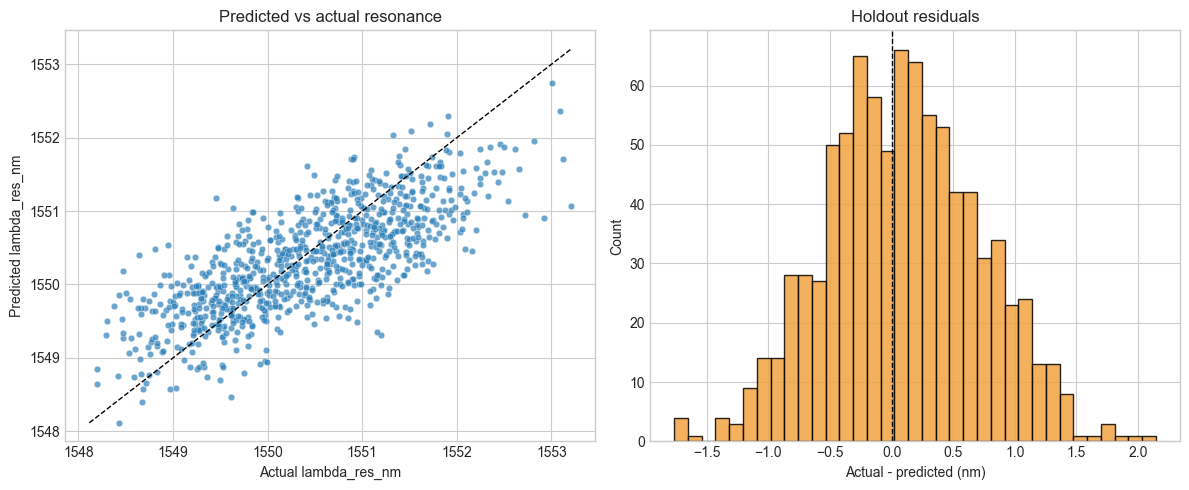

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(
    y_test,
    y_pred_linear,
    s=22,
    alpha=0.7,
    color="#2C7FB8",
    edgecolor="white",
    linewidth=0.3,
)
min_v = min(y_test.min(), y_pred_linear.min())
max_v = max(y_test.max(), y_pred_linear.max())
axes[0].plot([min_v, max_v], [min_v, max_v], color="black", linestyle="--", linewidth=1)
axes[0].set_title("Predicted vs actual resonance")
axes[0].set_xlabel("Actual lambda_res_nm")
axes[0].set_ylabel("Predicted lambda_res_nm")

residuals = y_test - y_pred_linear
axes[1].hist(residuals, bins=35, color="#F1A340", edgecolor="black", alpha=0.85)
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Holdout residuals")
axes[1].set_xlabel("Actual - predicted (nm)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

If the scatter follows the diagonal, the model has learned a useful signal. If the residuals are roughly centered around zero, there is no obvious global bias.

Some spread is expected. The target includes measurement noise, lot-level variation, wafer-level variation, spatial effects, and hidden true process state that is not perfectly observed by inline measurements.

## Final interpretation <a id="final-interpretation"></a>

This notebook uses only tested dies because only those dies have the downstream target `lambda_res_nm`.

The model uses only public inline metrology features. It avoids identifiers, downstream measurements, pass/fail labels, and hidden true generator variables to reduce leakage and keep the task realistic.

The split holds out complete wafers rather than random rows. This is a better fit for manufacturing-style data because dies from the same wafer are correlated.

The mean predictor provides a naive reference point. Linear Regression improves over that reference, which means the inline metrology features contain useful signal for predicting resonance wavelength in this synthetic dataset.

The strongest coefficients are expected to be waveguide width and silicon thickness. That supports the synthetic data story: the generator creates a learnable geometry-to-resonance signal that is visible in public measurements.

The result should not be overclaimed. It does not prove real-world fab performance. It shows that the synthetic benchmark is internally coherent and that a simple baseline can recover the intended physical signal.